# Modelo ML Long Short Term Memory

## 1. Liberias y carga de datos

In [2]:
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import prince as pr
import plotly.express as px
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import tensorflow as tf

In [ ]:
import src.utils.helpers as func
import sys
sys.path.append('../../')
# Usar df_log como dataset base para estos modelos
#path = r'C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_acumulado.parquet'
path = '../../data/processed/df_acumulado.parquet'

# Cargar datos (sin mostrar información para reducir salida de notebook)
df = func.load_data(path, show_info=False)

Cargando datos desde: C:\Users\naomi\proyecto_depresion\proyecto-integrador-mna\data\processed\df_acumulado.parquet
Datos cargados exitosamente.


## 2. Preparacion de datos

In [4]:
# Crear variable "valor" = incremento semanal del valor acumulado
df['valor'] = df['valor_acumulado_corregido'].diff().fillna(0)

# Corregir valores negativos o anómalos si existen
df['valor'] = df['valor'].apply(lambda x: x if x >= 0 else 0)

# Convertir a tipo float (evita errores en modelos)
df['valor'] = df['valor'].astype(float)

In [5]:
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week.astype(int)
df['trimestre'] = df['fecha'].dt.quarter
df['semestre'] = df['mes'].apply(lambda m: 1 if m <= 6 else 2)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

In [6]:
for lag in [1, 4, 12, 26, 52]:
    df[f'lag_{lag}'] = df['valor'].shift(lag)
df = df.dropna().reset_index(drop=True)

# Drop filas con NaN producto de lags/rolling
df = df.dropna().reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      521 non-null    datetime64[ns]
 1   valor_acumulado            521 non-null    float64       
 2   semana                     521 non-null    int64         
 3   rolling_mean               521 non-null    float64       
 4   rolling_std                521 non-null    float64       
 5   upper_bound                521 non-null    float64       
 6   lower_bound                521 non-null    float64       
 7   is_outlier                 521 non-null    bool          
 8   valor_acumulado_corregido  521 non-null    float64       
 9   mes                        521 non-null    int32         
 10  año                        521 non-null    int32         
 11  valor                      521 non-null    float64       
 12  trimestr

In [7]:
FEATURES = [
    "valor","lag_1","lag_4","lag_12","lag_26","lag_52",
    "mes_sin","mes_cos"
]
LOOKBACK   = 52      # semanas de historia que ve la red
TEST_WEEKS = 52      # tamaño del conjunto de test (último año)
VAL_WEEKS  = 26      # validación dentro del train para early stopping
SEED       = 42
tf.keras.utils.set_random_seed(SEED)
TARGET = "valor"

df_feat = df.sort_values("fecha").reset_index(drop=True)
train_df = df_feat.iloc[:-TEST_WEEKS].copy()
test_df  = df_feat.iloc[-(TEST_WEEKS+LOOKBACK):].copy()

scaler = StandardScaler()
X_train_full = scaler.fit_transform(train_df[FEATURES].values)
X_test_full  = scaler.transform(test_df[FEATURES].values)



In [8]:
def make_windows(arr, lookback, target_index=0):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i, :])   # ventana pasada
        y.append(arr[i, target_index])   # target escalado en t (next step)
    return np.array(X), np.array(y)

X_tr_all, y_tr_all = make_windows(X_train_full, LOOKBACK, target_index=0)  # target en índice 0 (valor)
# split interno para validación temprana
X_tr, y_tr = X_tr_all[:-VAL_WEEKS], y_tr_all[:-VAL_WEEKS]
X_va, y_va = X_tr_all[-VAL_WEEKS:],  y_tr_all[-VAL_WEEKS:]

X_te, y_te_scaled = make_windows(X_test_full, LOOKBACK, target_index=0)
# recuperar y_test en escala original
target_mean = scaler.mean_[FEATURES.index(TARGET)]
target_std  = scaler.scale_[FEATURES.index(TARGET)]
y_te = y_te_scaled * target_std + target_mean

In [9]:
def build_lstm(n_features, units=32, dropout=0.2, lr=1e-3):
    inp = tf.keras.Input(shape=(LOOKBACK, n_features))
    x = tf.keras.layers.LSTM(units, return_sequences=False)(inp)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mse")
    return model

n_features = len(FEATURES)
lstm = build_lstm(n_features, units=64, dropout=0.2, lr=1e-3)

cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)
]

hist = lstm.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=cb
)

# Predicción 1-paso en el bloque de test (ventanas deslizantes ya hechas)
y_pred_scaled = lstm.predict(X_te, verbose=0).ravel()
y_pred = y_pred_scaled * target_std + target_mean

mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
print(f"[LSTM 1-paso] Test -> MAE={mae:.2f}  RMSE={rmse:.2f}")

[LSTM 1-paso] Test -> MAE=369.37  RMSE=501.83


In [10]:
import keras_tuner as kt

def model_builder(hp):
    units = hp.Choice('units', [32, 64, 128])
    lr = hp.Choice('lr', [1e-2, 5e-3, 1e-3, 5e-4])
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, dropout=dropout, input_shape=(LOOKBACK, n_features)),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse')
    return model

tuner = kt.RandomSearch(
    model_builder, objective='val_loss', max_trials=10, overwrite=True,
    directory='tuning', project_name='lstm_forecast'
)

tuner.search(X_tr, y_tr, validation_data=(X_va, y_va), epochs=200, batch_size=16)
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 03m 25s]
val_loss: 0.3405674397945404

Best val_loss So Far: 0.3122522532939911
Total elapsed time: 00h 31m 30s


c:\Users\naomi\anaconda3\envs\depression-analysis\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [11]:
history = best_model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=200,
    batch_size=16,
    verbose=0
)

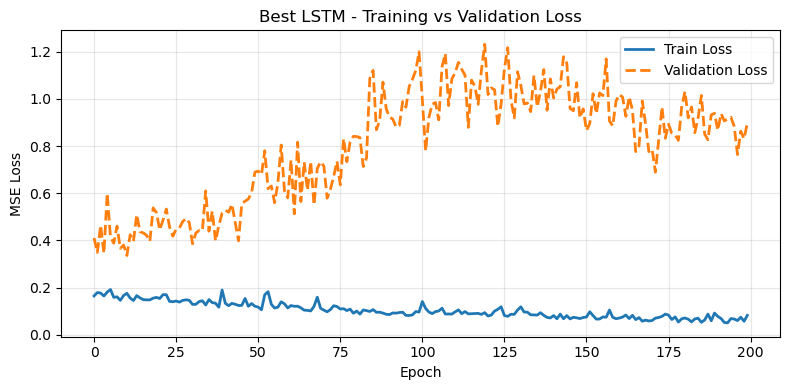

In [12]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--', linewidth=2)
plt.title("Best LSTM - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def recursive_forecast_lstm_with_features(
    model, 
    last_block_df,        # últimas LOOKBACK filas con columnas feat_cols en escala ORIGINAL
    scaler, 
    feat_cols, 
    lookback=52, 
    horizon=26,
    covid_start=pd.to_datetime("2020-03-01")
):
    """
    Devuelve DataFrame con columnas ['fecha','yhat'] (escala original) para las próximas 'horizon' semanas.
    Recalcula mes_sin/cos, semanas_desde_covid y tendencia; recalcula rolling_* usando SOLO historial previo.
    """
    assert len(last_block_df) >= lookback, "last_block_df debe tener al menos LOOKBACK filas"
    dfw = last_block_df.copy().reset_index(drop=True)

    # índices de utilidades
    target_idx = feat_cols.index("valor")
    target_mean = scaler.mean_[target_idx]
    target_std  = scaler.scale_[target_idx]

    # Estado inicial para determinísticos
    last_fecha = pd.to_datetime(dfw["fecha"].iloc[-1])
    last_tend  = int(dfw["tendencia"].iloc[-1])
    # Historial de valores originales (para rolling)
    history_vals = dfw["valor"].astype(float).tolist()

    preds, future_dates = [], []

    for step in range(horizon):
        # 1) Predicción para t+1 usando la ventana actual (LOOKBACK filas)
        X_window = scaler.transform(dfw[feat_cols].values)               # (lookback, n_features)
        X_window = X_window.reshape(1, lookback, -1)                     # (1, lookback, n_features)
        yhat_scaled = model.predict(X_window, verbose=0).ravel()[0]      # escala estandarizada del target
        yhat = yhat_scaled * target_std + target_mean                    # escala original

        # 2) Construir nueva fila t+1 en ESCALA ORIGINAL (para usar en la próxima ventana)
        next_date = last_fecha + pd.Timedelta(days=7)
        det = _compute_deterministics(next_date, covid_start, last_tend + 1)

        # rolling_* para la nueva fila: SOLO con valores pasados (antes de yhat)
        rolls = _recompute_rollings_from_series(history_vals, windows=(4,8,12,26))

        new_row = {
            "fecha": next_date,
            "valor": float(yhat),
            "mes_sin": det["mes_sin"],
            "mes_cos": det["mes_cos"],
            
        }

        # 3) Deslizar ventana
        dfw = pd.concat([dfw.iloc[1:], pd.DataFrame([new_row])], ignore_index=True)
        history_vals.append(yhat)         # ahora sí incorporamos yhat al historial
        last_fecha = next_date
        last_tend += 1

        preds.append(yhat)
        future_dates.append(next_date)

    return pd.DataFrame({"fecha": future_dates, "yhat": preds})


In [14]:
last_block = df_feat.tail(LOOKBACK).copy()

fc_4  = recursive_forecast_lstm_with_features(
    best_model, last_block, scaler, FEATURES, lookback=LOOKBACK, horizon=4
)

fc_26 = recursive_forecast_lstm_with_features(
    best_model, last_block, scaler, FEATURES, lookback=LOOKBACK, horizon=26
)

print(fc_4.head())
print(fc_26.tail())

KeyError: 'tendencia'